# Laboratorio 6 – K Nearest Neighbors (KNN)


In [10]:
import sys
print(sys.executable)

/Users/anggiequezada/Desktop/septimo semestre/Minsería/lab6-md/lab6-MD/nombre_entorno/bin/python


In [11]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy pyreadr scikit-learn

zsh:1: no such file or directory: /Users/anggiequezada/Desktop/septimo


In [12]:
# Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [13]:
# Cargar conjuntos de datos
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()  # precio (numérico)
y_test  = pd.read_csv('data/y_test.csv').squeeze()

# Cargar dataset con categoría de precio (barata, media, cara)
df_cat = pd.read_csv('data/df_con_categoria.csv')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print(f'\nColumnas en X_train:')
print(X_train.columns.tolist())

X_train: (52871, 20) | X_test: (22660, 20)
y_train: (52871,) | y_test: (22660,)

Columnas en X_train:
['room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable']


In [15]:
print(df_cat.columns.tolist())

['price', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable', 'precio_categoria']


In [16]:
# Extraer variable categórica de precio para clasificación
# Ajustar el nombre de la columna según el CSV real
col_categoria = 'precio_categoria'

y_train_cat = df_cat.loc[X_train.index, col_categoria]
y_test_cat  = df_cat.loc[X_test.index, col_categoria]

print('Distribución de categorías (train):')
print(y_train_cat.value_counts())

Distribución de categorías (train):
precio_categoria
Intermedia    27033
Cara          13508
Economica     12330
Name: count, dtype: int64


### 3. Preprocesamiento: Escalado de features

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado aplicado correctamente.')
print(f'Media aproximada post-escalado (train): {X_train_scaled.mean():.4f}')

Escalado aplicado correctamente.
Media aproximada post-escalado (train): -0.0000


### Punto 1 – Modelo KNN para Regresión (predicción de precio)

In [18]:
start_time = time.time()

knn_reg = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)  # p=2 → distancia Euclidiana
knn_reg.fit(X_train_scaled, y_train)

y_pred_reg = knn_reg.predict(X_test_scaled)

tiempo_reg = time.time() - start_time
print(f'Modelo entrenado y predicciones generadas en {tiempo_reg:.3f} segundos.')

Modelo entrenado y predicciones generadas en 0.421 segundos.


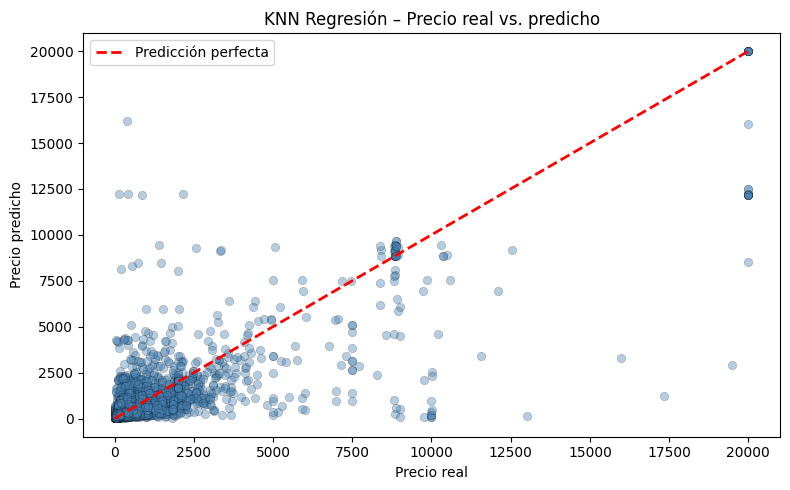

In [19]:
# Visualización: predicciones vs valores reales
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_reg, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('KNN Regresión – Precio real vs. predicho')
plt.legend()
plt.tight_layout()
plt.show()

### Punto 2 – Análisis de métricas del modelo de regresión

In [21]:
mae_reg  = mean_absolute_error(y_test, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2_reg   = r2_score(y_test, y_pred_reg)

print(' Métricas KNN Regresión (k=5) ')
print(f'  MAE  : {mae_reg:.4f}')
print(f'  RMSE : {rmse_reg:.4f}')
print(f'  R²   : {r2_reg:.4f}')
print(f'  Tiempo: {tiempo_reg:.3f} s')

 Métricas KNN Regresión (k=5) 
  MAE  : 156.0668
  RMSE : 556.2815
  R²   : 0.6340
  Tiempo: 0.421 s


#### Interpretación
> Completar después de ver los valores reales
> Analizar si el MAE/RMSE es aceptable en relación al rango de precios del dataset.  
> Un R² > 0.7 indicaría un modelo con capacidad predictiva razonable.  
> Si el R² es bajo, KNN podría estar teniendo dificultades con la alta dimensionalidad o la variabilidad del precio.

### Punto 3 – Comparación de modelos de regresión